# Time Series Data Import

In [62]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

stock_data=yf.download('AAPL',start = '2024-01-01')
stock_data.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.903214,186.677021,182.169586,185.399081,82488700
2024-01-03,182.526245,184.141000,181.713909,182.496527,58414500
2024-01-04,180.208115,181.377068,179.187752,180.445860,71983600
2024-01-05,179.484940,181.050159,178.484394,180.287374,62379700
2024-01-08,183.823990,183.863624,179.801976,180.386452,59144500
2024-01-09,183.407898,183.417799,181.020441,182.199311,42841800
2024-01-10,184.448059,184.656086,182.199292,182.625277,46792900
2024-01-11,183.853699,185.300046,181.902128,184.794808,49128400


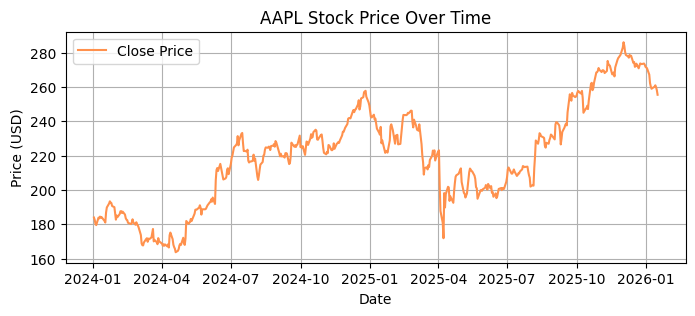

In [63]:
plt.figure(figsize=(8,3))
plt.plot(stock_data.index,stock_data['Close'],label='Close Price',color='#FF914D')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


# Classical Time Series Decomposition


In [64]:

from statsmodels.tsa.seasonal import seasonal_decompose
decomposition_additive = seasonal_decompose(stock_data[('Close', 'AAPL')], model='additive', period=30)

In [65]:
trend_additive=decomposition_additive.trend
seasonal_additive=decomposition_additive.seasonal
residual_additive=decomposition_additive.resid

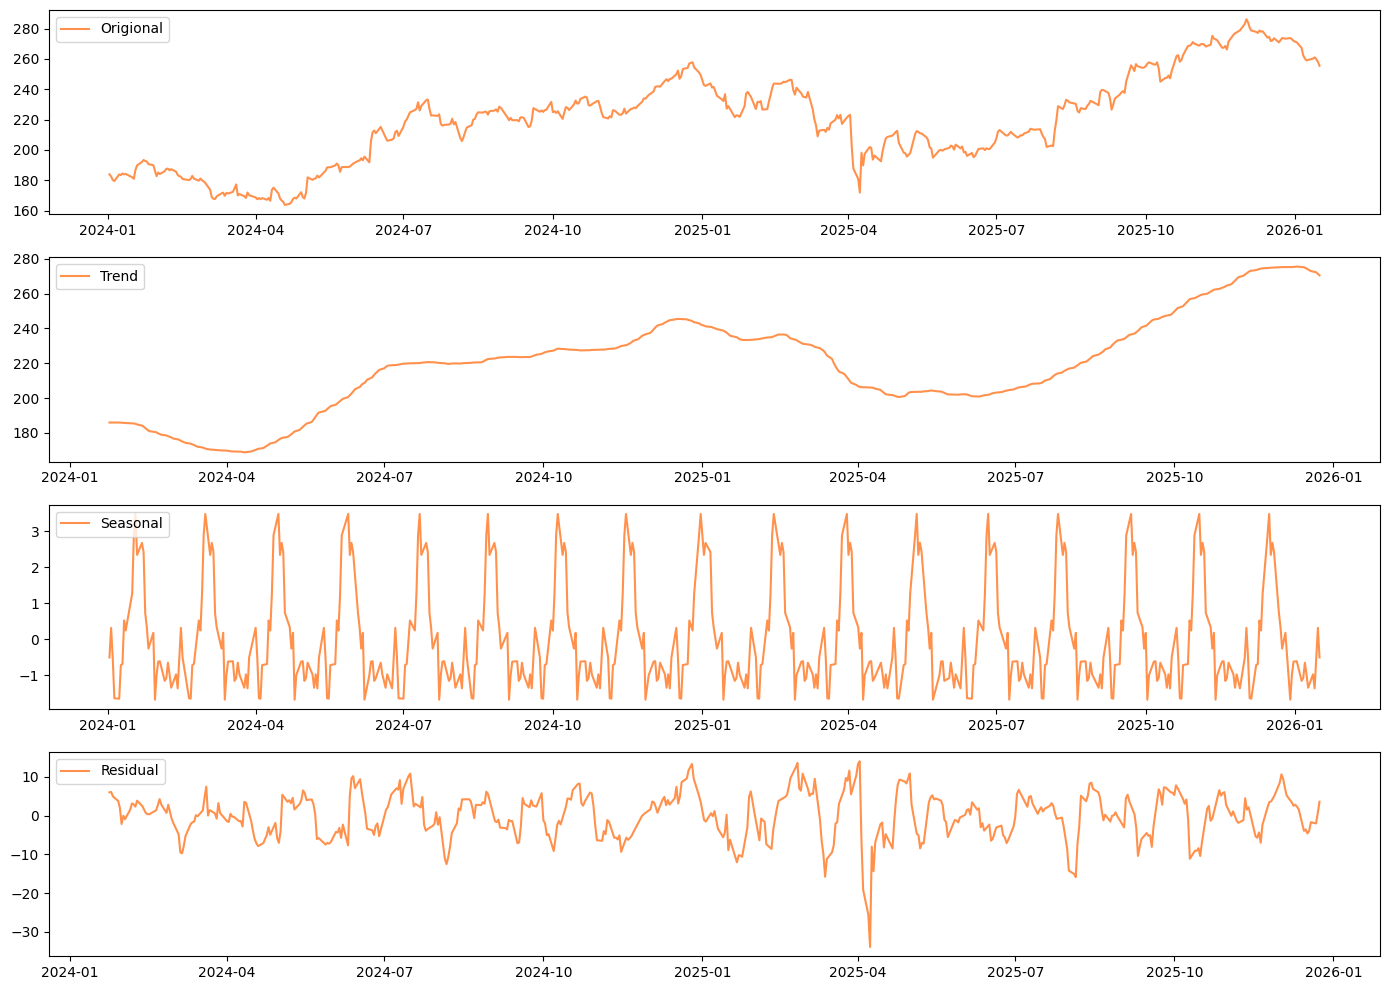

In [66]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(stock_data['Close'],label='Origional',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_additive,label='Trend',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_additive,label='Seasonal',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_additive,label='Residual',color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# STL Decomposition

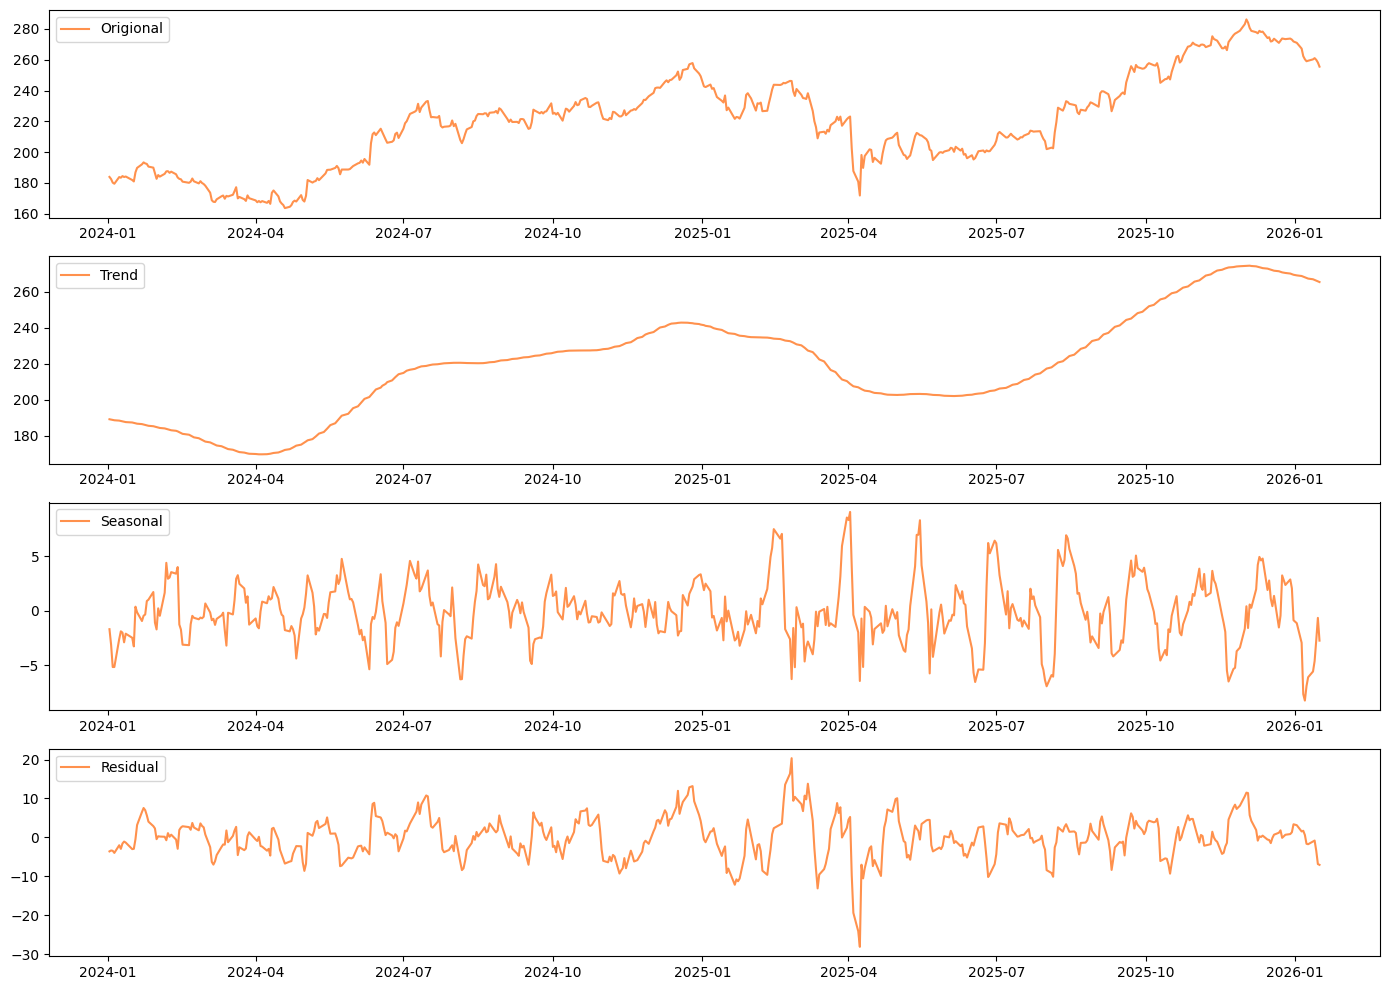

In [67]:
from statsmodels.tsa.seasonal import STL
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(result.observed,label='Origional',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend,label='Trend',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal,label='Seasonal',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid,label='Residual',color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


# Stationary Test

In [68]:
from statsmodels.tsa.stattools import adfuller
# perform the Argumented Dickey-Fullet Test
adf_test=adfuller(stock_data['Close'])
print("ADF Test Results:")
print(f"ADF Statistic: {adf_test[0]}")
print(f"P-Value: {adf_test[1]}")
print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"\t{key}: {value}")

ADF Test Results:
ADF Statistic: -1.5513305748218036
P-Value: 0.5079834890675736
Critical Values:
	1%: -3.443262740636999
	5%: -2.8672350350046787
	10%: -2.569803239025633


In [69]:
from statsmodels.tsa.stattools import kpss
# Perform the KPSS Test
kpss_test=kpss(stock_data['Close'],regression='ct')
print("\nKPSS Test Results:")
print(f"KPSS Statistic: {kpss_test[0]}")
print(f"P-Value: {kpss_test[1]}")
print("Critical Values:")
for key, value in kpss_test[3].items():
    print(f"\t{key}: {value}")


KPSS Test Results:
KPSS Statistic: 0.2885717238768435
P-Value: 0.01
Critical Values:
	10%: 0.119
	5%: 0.146
	2.5%: 0.176
	1%: 0.216


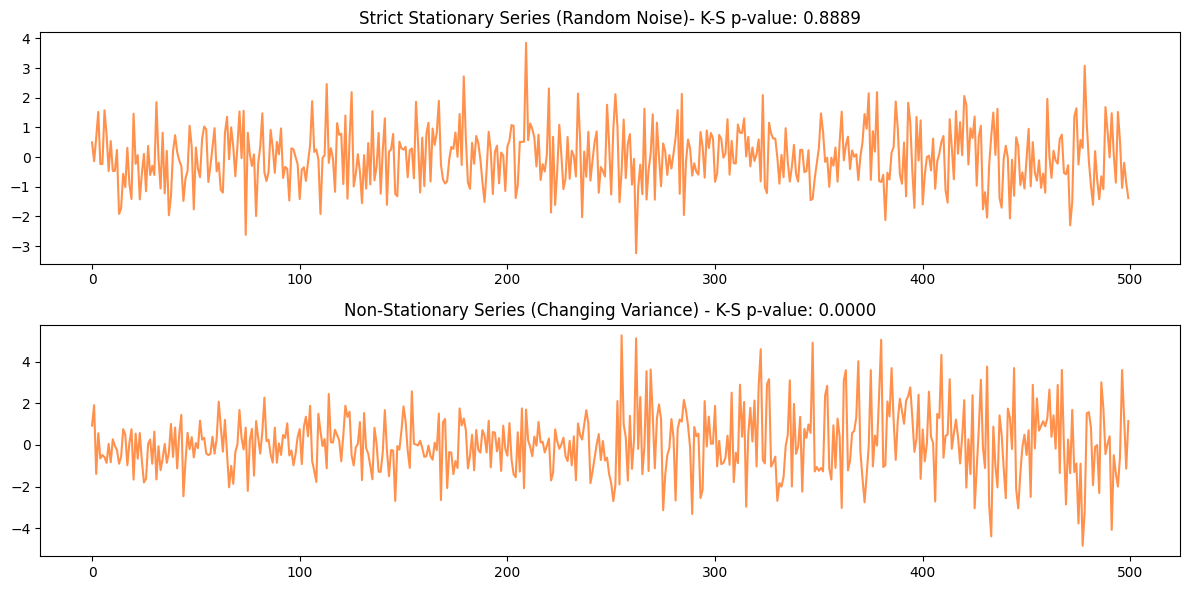

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating synthetic data for demonstration of strict stationary
np.random.seed(42)
n=500

# Strict stationary series: normally distributed random noise
strict_stationary_series=np.random.normal(0,1,n)

# Non-stationary series: changing variance
non_strict_stationary_series=np.concatenate([
    np.random.normal(0,1,n//2),
    np.random.normal(0,2,n//2)
])

# Function to split series into two halves and perform K-S test
def ks_test_stationary(series):
    split=len(series)//2
    series_first_half=series[:split]
    series_second_half=series[split:]
    stat,p_value=ks_2samp(series_first_half,series_second_half  )
    return stat,p_value

# perform K-S test on Strict Stationary series
ks_stat_strict,ks_pvalue_strict=ks_test_stationary(strict_stationary_series)

# perform K-S test on Non-Stationary series
ks_stat_non_strict,ks_pvalue_non_strict=ks_test_stationary(non_strict_stationary_series)

#Plotting Series
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(strict_stationary_series,color='#FF914D')
plt.title(f'Strict Stationary Series (Random Noise)- K-S p-value: {ks_pvalue_strict:.4f}')
plt.subplot(2,1,2)
plt.plot(non_strict_stationary_series,color='#FF914D')
plt.title(f'Non-Stationary Series (Changing Variance) - K-S p-value: {ks_pvalue_non_strict:.4f}')
plt.tight_layout()
plt.show()


# Making Data Stationary

In [71]:
# Performing ADF and KPSS test
def adf_test(series):
    result=adfuller(series)
    print("ADF Stats : ", result[0])
    print("p-value : ", result[1])
    for key, value in result[4].items():
        print('Critical Value(%s):%.3f' % (key, value))

def kpss_test(series):
    result=kpss(series,regression='ct')
    print("KPSS Stats : ", result[0])
    print("p-value : ", result[1])
    for key, value in result[3].items():
        print('Critical Value(%s):%.3f' % (key, value))

In [72]:
prices=stock_data['Close']

In [73]:
adf_test(prices)

ADF Stats :  -1.5513305748218036
p-value :  0.5079834890675736
Critical Value(1%):-3.443
Critical Value(5%):-2.867
Critical Value(10%):-2.570


In [74]:
# for finding the forst order differencing we will use .diff() and for second order .diff().diff()
first_diff=prices.diff()
second_diff=first_diff.diff()
print(first_diff.head())
print(second_diff.head())

Ticker          AAPL
Date                
2024-01-02       NaN
2024-01-03 -1.376968
2024-01-04 -2.318130
2024-01-05 -0.723175
2024-01-08  4.339050
Ticker          AAPL
Date                
2024-01-02       NaN
2024-01-03       NaN
2024-01-04 -0.941162
2024-01-05  1.594955
2024-01-08  5.062225


In [75]:
adf_test(prices.diff().dropna())

ADF Stats :  -13.183847065957343
p-value :  1.181083074305686e-24
Critical Value(1%):-3.443
Critical Value(5%):-2.867
Critical Value(10%):-2.570


### Transformation

In [76]:
import numpy as np
from scipy import stats

# log transform
prices_log=np.log(prices)

# power transform
prices_sqrt=np.sqrt(prices)

# box-cox transformation
# NOTE: Box-Cox only taked positive values
prices_boxcox,lam=stats.boxcox(prices[prices>0].dropna().values.flatten())

In [77]:
prices_log

Ticker,AAPL
Date,
2024-01-02,5.214410
2024-01-03,5.206894
2024-01-04,5.194112
2024-01-05,5.190091
2024-01-08,5.213979
...,...
2026-01-12,5.561643
2026-01-13,5.564712
2026-01-14,5.560528


In [78]:
prices_sqrt

Ticker,AAPL
Date,
2024-01-02,13.561092
2024-01-03,13.510227
2024-01-04,13.424162
2024-01-05,13.397199
2024-01-08,13.558171
...,...
2026-01-12,16.132266
2026-01-13,16.157041
2026-01-14,16.123275


In [79]:
prices_boxcox

array([29.00273631, 28.87793614, 28.66685056, 28.6007436 , 28.99556766,
       28.95789362, 29.05199891, 28.99825607, 29.02782507, 28.82212777,
       28.73644759, 29.26974818, 29.52951302, 29.73478017, 29.84793805,
       29.78833313, 29.75937164, 29.60540934, 29.54452718, 29.21721527,
       28.89142429, 29.11192111, 29.02155555, 29.18512198, 29.32931123,
       29.33908169, 29.24215609, 29.31073852, 29.15914678, 28.97010687,
       28.89007266, 28.8639551 , 28.72404195, 28.65614512, 28.72494769,
       28.90987262, 28.7430326 , 28.61988082, 28.75297249, 28.6434536 ,
       28.58267168, 28.48355927, 28.0658841 , 27.60397176, 27.51047029,
       27.49923549, 27.66088525, 27.84867784, 27.89315369, 27.69815288,
       27.87185149, 27.83662224, 27.93849607, 28.15606538, 28.39329719,
       27.72049248, 27.80507471, 27.6720689 , 27.56566753, 27.90056152,
       27.73072522, 27.59556779, 27.48424524, 27.56005745, 27.48236992,
       27.55351286, 27.4476832 , 27.56192997, 27.38478094, 28.06

In [ ]:
adf_test(prices_sqrt)
# p-value is very high(>0.05) so after this transformation we aren't getting  stationary data

ADF Stats :  -1.5833544032988487
p-value :  0.49194953172804584
Critical Value(1%):-3.443
Critical Value(5%):-2.867
Critical Value(10%):-2.570


In [81]:
adf_test(prices_boxcox)

ADF Stats :  -1.5807744896616331
p-value :  0.49324350866279715
Critical Value(1%):-3.443
Critical Value(5%):-2.867
Critical Value(10%):-2.570


In [82]:
adf_test(prices.diff().dropna())

ADF Stats :  -13.183847065957343
p-value :  1.181083074305686e-24
Critical Value(1%):-3.443
Critical Value(5%):-2.867
Critical Value(10%):-2.570


### Detrending

In [90]:
from scipy import signal

# using linear trend
trend = np.polyfit(np.arange(len(prices)), prices.values.flatten(), 1)
trendline = np.polyval(trend, np.arange(len(prices)))
prices_detrended = (prices.values.flatten() - trendline)

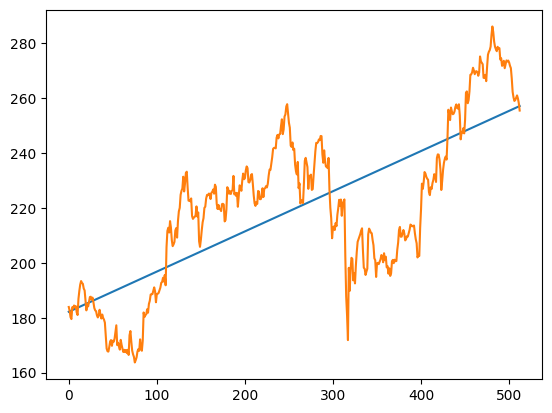

In [91]:
plt.plot(np.arange(len(prices)), trendline)
plt.plot(np.arange(len(prices)), prices)
plt.show()

In [92]:
adf_test(prices_detrended)

ADF Stats :  -2.2006310829598856
p-value :  0.20601648988040672
Critical Value(1%):-3.443
Critical Value(5%):-2.867
Critical Value(10%):-2.570


In [93]:
from statsmodels.tsa.seasonal import seasonal_decompose

# seasonal decomposition using moving averages
decomposition = seasonal_decompose(prices, model='additive', period=30)
prices_adjusted=prices/decomposition.seasonal
prices_adjusted=prices_adjusted.dropna()

In [94]:
adf_test(prices_adjusted)

ValueError: x is required to have ndim 1 but has ndim 2